# Results Comparison

## Aim of this notebook
This notebook provides a comparative evaluation of the three submitted techniques using a single shared evaluation protocol.  The goal is to produce an evidence based comparison that is clear, reproducible, and aligned with the project requirements for Part 3.

## What will be produced in this notebook
Performance comparison outputs:  

1. A comprehensive metrics table covering all techniques, including headline metrics and timing measures  .

2. Statistical significance testing to assess whether observed performance differences are likely meaningful rather than due to sampling variation.

3. Visualisations including side by side ROC curves where score outputs are available, metric comparison plots, and confusion matrices.

4. Feature importance or interpretability evidence for each technique, using the most appropriate method supported by that model family.  

5. A trade off analysis discussing accuracy versus interpretability, complexity versus performance, and training time versus prediction speed.

Ethical and deployment analysis:

6. A critical ethical analysis focusing on proxy variables such as location, potential temporal bias, and fairness across available groups.

7. Deployment risk discussion covering false positive and false negative costs, potential policy impacts, and feedback loop risks.

8. Recommendations that specify which technique or combination of techniques is most suitable for deployment, alongside safeguards, monitoring, and human oversight considerations.

In [ ]:
# Imports and settings

import time
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import auc
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, Ridge, Ridge based linear approach
from sklearn.model_selection import train_test_split
from pathlib import Path
from sklearn import metrics
from typing import Any, Dict, Optional, Tuple
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize


warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 80)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

In [52]:
# Environment capture for reproducibility

import sys
import sklearn
import pandas as pd

print("Python version:", sys.version.replace("\n", " "))
print("scikit-learn version:", sklearn.__version__)
print("pandas version:", pd.__version__)

Python version: 3.13.2 (main, Feb  4 2025, 14:51:09) [Clang 16.0.0 (clang-1600.0.26.6)]
scikit-learn version: 1.8.0
pandas version: 2.3.3


## Reproducibility and constraints

The three technique notebooks are treated as fixed submissions and will not be modified.  This results notebook is responsible for producing a fair, consistent comparison by applying the same data split and the same metric set across all techniques.

To ensure fairness, a single shared train test split will be created once and then reused for every model.  Likewise, all techniques will be evaluated using the same core classification metrics, and visualisations will be generated using the same test set and class ordering.  Where a technique does not expose probability style scores needed for ROC analysis, this limitation will be stated explicitly and the remaining comparisons will still be reported consistently.

In [10]:
candidate_paths = [
    "Datasets/Finalized_Dataset.csv",
    "Finalized_Dataset.csv",
    "/mnt/data/Finalized_Dataset.csv",
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find Finalized_Dataset.csv.  Checked: "
        + ", ".join(candidate_paths)
    )

df = pd.read_csv(data_path)

TARGET_COL = "severity_label"
if TARGET_COL not in df.columns:
    raise ValueError(f"Expected target column '{TARGET_COL}' in {data_path}")

print(f"Loaded dataset from: {data_path}")
print(f"Shape: {df.shape}")

print("\nColumns:")
print(list(df.columns))

print("\nColumns  one per line:")
for col in df.columns:
    print(col)

print("\nTarget class distribution:")
print(df[TARGET_COL].value_counts(dropna=False))

Loaded dataset from: Datasets/Finalized_Dataset.csv
Shape: (432, 16)

Columns:
['content', 'temperature_2m_mean', 'apparent_temperature_mean', 'precipitation_sum', 'precipitation_hours', 'wind_speed_10m_max', 'is_holiday', 'month', 'tag_National', 'tag_Accident', 'tag_Traffic', 'tag_Police', 'tag_Transport', 'dow_sin', 'dow_cos', 'severity_label']

Columns  one per line:
content
temperature_2m_mean
apparent_temperature_mean
precipitation_sum
precipitation_hours
wind_speed_10m_max
is_holiday
month
tag_National
tag_Accident
tag_Traffic
tag_Police
tag_Transport
dow_sin
dow_cos
severity_label

Target class distribution:
severity_label
3    194
4     89
2     71
1     44
0     34
Name: count, dtype: int64


## Comparison approach used in this notebook

A like for like comparison is only valid when techniques are evaluated under the same conditions.  Where the three technique notebooks provide directly comparable evaluation outputs, meaning the same train test split, consistent target encoding, and the necessary predictions or score outputs, these results are reused to construct the comparison tables and figures.

Where direct comparability cannot be guaranteed, this notebook recomputes only the final training and evaluation step for each technique using a single shared train test split defined here.  This limited rerun is performed solely to produce consistent metrics and visualisations for comparison.

## Inputs and target definition

The dataset is treated as a supervised multi class classification problem.  The outcome variable used throughout this comparison is **severity_label**, which represents the class to be predicted for each record.

All remaining columns are considered potential input features, subject to basic exclusions required for a valid evaluation.  Where present, identifier style fields such as record IDs are excluded from modelling because they carry no generalisable signal.  Text based fields are treated as unstructured inputs for vectorisation, while numeric and categorical fields are treated as structured predictors.  Any rows with missing values in **severity_label** are removed to avoid introducing ambiguous labels into training and evaluation.

A single shared train test split is required to ensure that performance differences reflect the modelling technique rather than differences in sampling.  Using the same split guarantees that each model is trained on the same observations and evaluated on the same held out cases, enabling a fair comparison across metrics, visualisations, and statistical tests.

In [9]:
SPLIT_FILE = Path("shared_split_indices.npz")

# Ensure we only split rows with a valid target
df_split = df.dropna(subset=[TARGET_COL]).copy()

y_all = df_split[TARGET_COL]

# Use stratification when it is feasible
value_counts = y_all.value_counts()
can_stratify = (y_all.nunique() > 1) and (value_counts.min() >= 2)

if SPLIT_FILE.exists():
    loaded = np.load(SPLIT_FILE, allow_pickle=True)
    train_idx = loaded["train_idx"]
    test_idx = loaded["test_idx"]
    print("Loaded existing split indices from:", SPLIT_FILE.resolve())
else:
    all_idx = df_split.index.to_numpy()

    train_idx, test_idx = train_test_split(
        all_idx,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=y_all if can_stratify else None
    )

    np.savez(SPLIT_FILE, train_idx=train_idx, test_idx=test_idx)
    print("Created and saved split indices to:", SPLIT_FILE.resolve())

# Reload immediately to confirm the saved file works and indices are identical
loaded_check = np.load(SPLIT_FILE, allow_pickle=True)
train_idx_check = loaded_check["train_idx"]
test_idx_check = loaded_check["test_idx"]

assert np.array_equal(train_idx, train_idx_check), "Train indices mismatch after reload"
assert np.array_equal(test_idx, test_idx_check), "Test indices mismatch after reload"

print("\nSplit summary")
print("Total rows used for splitting:", len(df_split))
print("Train rows:", len(train_idx), "Test rows:", len(test_idx))
print("Stratified:", can_stratify)

# Convenience views for later cells
df_train = df.loc[train_idx].copy()
df_test = df.loc[test_idx].copy()

print("\nTarget distribution in train")
print(df_train[TARGET_COL].value_counts(normalize=True).round(4))

print("\nTarget distribution in test")
print(df_test[TARGET_COL].value_counts(normalize=True).round(4))

Created and saved split indices to: /Users/lucadascari/Documents/University/Masters/AML/Applied-Machine-Learning--ICS5110--Assignment/shared_split_indices.npz

Split summary
Total rows used for splitting: 432
Train rows: 345 Test rows: 87
Stratified: True

Target distribution in train
severity_label
3    0.4493
4    0.2058
2    0.1652
1    0.1014
0    0.0783
Name: proportion, dtype: float64

Target distribution in test
severity_label
3    0.4483
4    0.2069
2    0.1609
1    0.1034
0    0.0805
Name: proportion, dtype: float64


## Metric set used for all techniques

All techniques are evaluated using the same held out test set and the same core classification metrics to ensure comparability.

The following metrics are reported for each technique:

Overall performance: 
• Accuracy  
• Macro averaged F1 score, to reflect performance across classes equally  
• Weighted F1 score, to reflect performance while accounting for class imbalance  

Class level performance:  
• Precision, recall, and F1 score for each class  
• Confusion matrix using a consistent class ordering  

ROC based evaluation:  
• Macro averaged ROC AUC using a one versus rest approach where continuous scores are available, such as predicted probabilities or decision scores  
Where a technique does not provide suitable score outputs, ROC based results are not reported for that technique and the limitation is stated explicitly.

Computational trade offs:  
• Training time  
• Prediction time on the test set

In [14]:
def compute_classification_metrics(
    y_true,
    y_pred,
    scores: Optional[np.ndarray] = None,
    class_labels: Optional[np.ndarray] = None,
) -> Dict[str, Any]:
    """
    Compute a consistent set of classification metrics.

    scores is optional.
    For multiclass ROC AUC it should be an array of shape (n_samples, n_classes)
    containing probability like scores or decision scores per class.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if class_labels is None:
        class_labels = np.unique(y_true)

    out: Dict[str, Any] = {}

    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    out["macro_f1"] = float(f1_score(y_true, y_pred, average="macro"))
    out["weighted_f1"] = float(f1_score(y_true, y_pred, average="weighted"))

    out["confusion_matrix"] = confusion_matrix(y_true, y_pred, labels=class_labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=class_labels,
        output_dict=True,
        zero_division=0
    )
    out["classification_report"] = report

    roc_available = False
    roc_auc_macro = None

    if scores is not None:
        scores = np.asarray(scores)

        if scores.ndim == 2 and scores.shape[0] == len(y_true) and scores.shape[1] == len(class_labels):
            try:
                y_true_bin = label_binarize(y_true, classes=class_labels)
                roc_auc_macro = float(
                    roc_auc_score(
                        y_true_bin,
                        scores,
                        average="macro",
                        multi_class="ovr"
                    )
                )
                roc_available = True
            except Exception:
                roc_available = False
                roc_auc_macro = None

    out["roc_available"] = roc_available
    out["roc_auc_macro_ovr"] = roc_auc_macro

    return out


def time_fit_predict(
    model,
    X_train,
    y_train,
    X_test,
) -> Tuple[Any, float, float, np.ndarray, Optional[np.ndarray], str]:
    """
    Fit a model and time training and prediction.

    Returns:
    fitted_model, train_seconds, predict_seconds, y_pred, scores, score_type

    scores is one of:
    predict_proba output, decision_function output, or None if unavailable.
    score_type describes which one was used.
    """
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_seconds = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_seconds = time.perf_counter() - t1

    scores = None
    score_type = "none"

    if hasattr(model, "predict_proba"):
        try:
            scores = model.predict_proba(X_test)
            score_type = "predict_proba"
        except Exception:
            scores = None
            score_type = "none"

    if scores is None and hasattr(model, "decision_function"):
        try:
            scores = model.decision_function(X_test)
            score_type = "decision_function"
        except Exception:
            scores = None
            score_type = "none"

    if scores is not None:
        scores = np.asarray(scores)

        if scores.ndim == 1:
            # Binary decision_function sometimes returns shape (n_samples,)
            scores = scores.reshape(-1, 1)

    return model, float(train_seconds), float(predict_seconds), np.asarray(y_pred), scores, score_type


def one_vs_rest_roc(
    y_true,
    scores: np.ndarray,
    class_labels: Optional[np.ndarray] = None,
) -> Dict[str, Any]:
    """
    Compute one versus rest ROC curves and macro AUC for multiclass.

    Returns dict with:
    fpr, tpr per class, auc per class, macro_auc, class_labels.
    """
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    if class_labels is None:
        class_labels = np.unique(y_true)

    if scores.ndim != 2 or scores.shape[0] != len(y_true) or scores.shape[1] != len(class_labels):
        raise ValueError(
            "scores must have shape (n_samples, n_classes) matching y_true and class_labels."
        )

    y_true_bin = label_binarize(y_true, classes=class_labels)

    fpr = {}
    tpr = {}
    aucs = {}

    for i, c in enumerate(class_labels):
        fpr[c], tpr[c], _ = roc_curve(y_true_bin[:, i], scores[:, i])
        aucs[c] = float(roc_auc_score(y_true_bin[:, i], scores[:, i]))

    macro_auc = float(
        roc_auc_score(
            y_true_bin,
            scores,
            average="macro",
            multi_class="ovr"
        )
    )

    return {
        "class_labels": class_labels,
        "fpr": fpr,
        "tpr": tpr,
        "auc_per_class": aucs,
        "macro_auc_ovr": macro_auc,
    }

print("Helper functions loaded:", compute_classification_metrics.__name__, time_fit_predict.__name__, one_vs_rest_roc.__name__)

Helper functions loaded: compute_classification_metrics time_fit_predict one_vs_rest_roc


## Model definitions used for comparison

Three models are defined in this notebook to enable a consistent comparison and evaluation.  Each model is implemented to match the corresponding technique notebook as closely as possible, including the same feature preparation approach and the same key hyperparameters reported in those notebooks.

The purpose of redefining the models here is not to repeat exploratory work, but to ensure that all techniques are trained and evaluated on the same train and test data, with the same metric definitions.  This provides a fair basis for comparison across performance, interpretability, computational cost, and deployment considerations.

In [ ]:
# Feature selection and split views

# Start from all columns except the target.
feature_cols = [c for c in df.columns if c != TARGET_COL]

def looks_like_identifier(col_name: str) -> bool:
    name = col_name.strip().lower()

    # Common exact identifier names
    if name in {"id", "index"}:
        return True

    # Common identifier patterns
    if name.endswith("_id") or name.endswith("id"):
        return True
    if "record_id" in name or "article_id" in name:
        return True

    return False

id_like = [c for c in feature_cols if looks_like_identifier(c)]
feature_cols = [c for c in feature_cols if c not in id_like]

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

# Use the frozen indices created in Cell 8
X_train = X.loc[train_idx].copy()
X_test = X.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()

# Detect column types
# Object dtype is treated as text here.  If you later discover object columns that are truly categorical,
# we can move them into categorical_cols.
text_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
numeric_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
categorical_cols = [c for c in X_train.columns if (c not in text_cols and c not in numeric_cols)]

print("Feature columns used:", len(feature_cols))
print("Dropped identifier columns:", id_like)
print("Detected text columns:", text_cols)
print("Detected numeric columns:", numeric_cols)
print("Detected categorical columns:", categorical_cols)



# Text joiner
# If multiple text columns exist, join them into one string per row so TF IDF can be applied consistently.

class TextJoiner(BaseEstimator, TransformerMixin):
    def fit(self, X_in, y=None):
        return self

    def transform(self, X_in):
        X_work = X_in.copy() if isinstance(X_in, pd.DataFrame) else pd.DataFrame(X_in)
        X_work = X_work.fillna("")
        joined = X_work.astype(str).agg(" ".join, axis=1)
        return joined.to_numpy()


# Shared preprocessing for all techniques

# Text features: TF IDF vectorisation on the combined text
# Numeric features: scaling to keep magnitudes comparable for SVM and linear models
# Categorical features: one hot encoding if any categorical columns exist

text_pipeline = Pipeline(
    steps=[
        ("join", TextJoiner()),
        ("tfidf", TfidfVectorizer()),
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

transformers = []

if len(text_cols) > 0:
    transformers.append(("text", text_pipeline, text_cols))

if len(numeric_cols) > 0:
    transformers.append(("num", numeric_pipeline, numeric_cols))

if len(categorical_cols) > 0:
    transformers.append(("cat", categorical_pipeline, categorical_cols))

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")


# Technique models

rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# SVC default probability=False.  For ROC, decision_function scores may still be available.
svm_clf = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale"
)

# Linear baseline: Ridge based linear approach is a proper multiclass classifier and is cleaner than rounding regression outputs.
ridge_clf = Ridge based linear approach(alpha=1.0, random_state=RANDOM_SEED)


# Final pipelines for comparison

rf_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", rf_clf)])
svm_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", svm_clf)])
linear_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", ridge_clf)])

print("\nPipelines instantiated")
print("Random Forest pipeline:", rf_pipeline)
print("SVM pipeline:", svm_pipeline)
print("Linear baseline pipeline:", linear_pipeline)

Feature columns used: 15
Dropped identifier columns: []
Detected text columns: ['content']
Detected numeric columns: ['temperature_2m_mean', 'apparent_temperature_mean', 'precipitation_sum', 'precipitation_hours', 'wind_speed_10m_max', 'is_holiday', 'month', 'tag_National', 'tag_Accident', 'tag_Traffic', 'tag_Police', 'tag_Transport', 'dow_sin', 'dow_cos']
Detected categorical columns: []

Pipelines instantiated
Random Forest pipeline: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('join',
                                                                   TextJoiner()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer())]),
                                                  ['content']),
                                                 ('num',
                            

In [ ]:
# Feature selection and split views

# Start from all columns except the target.
# Drop columns that look like identifiers, because IDs do not generalise and can leak information.
feature_cols = [c for c in df.columns if c != TARGET_COL]

def looks_like_identifier(col_name: str) -> bool:
    name = col_name.strip().lower()

    # Common exact identifier names
    if name in {"id", "index"}:
        return True

    # Common identifier patterns
    if name.endswith("_id") or name.endswith("id"):
        return True
    if "record_id" in name or "article_id" in name:
        return True

    return False

id_like = [c for c in feature_cols if looks_like_identifier(c)]
feature_cols = [c for c in feature_cols if c not in id_like]

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

# Use the frozen indices created in Cell 8
X_train = X.loc[train_idx].copy()
X_test = X.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()

# Detect column types
# Object dtype is treated as text here.  If you later discover object columns that are truly categorical,
# we can move them into categorical_cols.
text_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
numeric_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
categorical_cols = [c for c in X_train.columns if (c not in text_cols and c not in numeric_cols)]

print("Feature columns used:", len(feature_cols))
print("Dropped identifier columns:", id_like)
print("Detected text columns:", text_cols)
print("Detected numeric columns:", numeric_cols)
print("Detected categorical columns:", categorical_cols)

# Text joiner
# If multiple text columns exist, join them into one string per row so TF IDF can be applied consistently.

class TextJoiner(BaseEstimator, TransformerMixin):
    def fit(self, X_in, y=None):
        return self

    def transform(self, X_in):
        X_work = X_in.copy() if isinstance(X_in, pd.DataFrame) else pd.DataFrame(X_in)
        X_work = X_work.fillna("")
        joined = X_work.astype(str).agg(" ".join, axis=1)
        return joined.to_numpy()


# Shared preprocessing for all techniques

# Text features: TF IDF vectorisation on the combined text
# Numeric features: scaling to keep magnitudes comparable for SVM and linear models
# Categorical features: one hot encoding if any categorical columns exist

text_pipeline = Pipeline(
    steps=[
        ("join", TextJoiner()),
        ("tfidf", TfidfVectorizer()),
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

transformers = []

if len(text_cols) > 0:
    transformers.append(("text", text_pipeline, text_cols))

if len(numeric_cols) > 0:
    transformers.append(("num", numeric_pipeline, numeric_cols))

if len(categorical_cols) > 0:
    transformers.append(("cat", categorical_pipeline, categorical_cols))

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")



# Technique models

# These are baseline hyperparameters.
# Replace them later if the technique notebooks specify different final settings.

rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# SVC default probability=False.  For ROC, decision_function scores may still be available.
svm_clf = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale"
)

# Linear baseline: Ridge based linear approach is a proper multiclass classifier and is cleaner than rounding regression outputs.
ridge_clf = Ridge based linear approach(alpha=1.0, random_state=RANDOM_SEED)



# Final pipelines for comparison

rf_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", rf_clf)])
svm_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", svm_clf)])
linear_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", ridge_clf)])

print("\nPipelines instantiated")
print("Random Forest pipeline:", rf_pipeline)
print("SVM pipeline:", svm_pipeline)
print("Linear baseline pipeline:", linear_pipeline)

Feature columns used: 15
Dropped identifier columns: []
Detected text columns: ['content']
Detected numeric columns: ['temperature_2m_mean', 'apparent_temperature_mean', 'precipitation_sum', 'precipitation_hours', 'wind_speed_10m_max', 'is_holiday', 'month', 'tag_National', 'tag_Accident', 'tag_Traffic', 'tag_Police', 'tag_Transport', 'dow_sin', 'dow_cos']
Detected categorical columns: []

Pipelines instantiated
Random Forest pipeline: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('join',
                                                                   TextJoiner()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer())]),
                                                  ['content']),
                                                 ('num',
                            

## Training and evaluation on the shared split

All techniques are trained and evaluated under identical conditions.  Each model is fitted using the same training rows defined by the frozen indices created earlier, and each is evaluated on the same held out test rows.  This ensures that any observed performance differences are attributable to the modelling approach rather than differences in sampling, preprocessing, or evaluation setup.

In [20]:
# Create storage containers once, then reuse for the other techniques
if "results" not in globals():
    results = {}
if "predictions" not in globals():
    predictions = {}
if "score_outputs" not in globals():
    score_outputs = {}
if "timings" not in globals():
    timings = {}

# Fix class ordering once so confusion matrices and reports are consistent across models
class_labels = np.sort(y_train.dropna().unique())

rf_fitted, rf_train_s, rf_pred_s, rf_y_pred, rf_scores, rf_score_type = time_fit_predict(
    rf_pipeline,
    X_train,
    y_train,
    X_test
)

rf_metrics = compute_classification_metrics(
    y_true=y_test,
    y_pred=rf_y_pred,
    scores=rf_scores,
    class_labels=class_labels
)

# Store everything for later cells (tables, plots, significance tests)
results["Random Forest"] = rf_metrics
predictions["Random Forest"] = rf_y_pred
score_outputs["Random Forest"] = {"scores": rf_scores, "score_type": rf_score_type}
timings["Random Forest"] = {"train_seconds": rf_train_s, "predict_seconds": rf_pred_s}

# Quick summary output for the notebook narrative
print("Random Forest evaluation complete")
print(f"Training time (s): {rf_train_s:.4f}")
print(f"Prediction time (s): {rf_pred_s:.4f}")
print(f"Accuracy: {rf_metrics['accuracy']:.4f}")
print(f"Macro F1: {rf_metrics['macro_f1']:.4f}")
print(f"Weighted F1: {rf_metrics['weighted_f1']:.4f}")

if rf_metrics["roc_available"]:
    print(f"Macro ROC AUC (OvR): {rf_metrics['roc_auc_macro_ovr']:.4f}")
else:
    print("Macro ROC AUC (OvR): Not available for this technique")

# Display the per class report in a readable table
rf_report_df = pd.DataFrame(rf_metrics["classification_report"]).T
display(rf_report_df)

Random Forest evaluation complete
Training time (s): 0.2142
Prediction time (s): 0.0328
Accuracy: 0.7471
Macro F1: 0.6774
Weighted F1: 0.7115
Macro ROC AUC (OvR): 0.9415


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,7.000000
1,0.750000,0.333333,0.461538,9.000000
2,1.000000,0.214286,0.352941,14.000000
3,0.777778,0.897436,0.833333,39.000000
4,0.607143,0.944444,0.739130,18.000000
accuracy,0.747126,0.747126,0.747126,0.747126
macro avg,0.826984,0.677900,0.677389,87.000000
weighted avg,0.793240,0.747126,0.711487,87.000000


In [21]:
svm_fitted, svm_train_s, svm_pred_s, svm_y_pred, svm_scores, svm_score_type = time_fit_predict(
    svm_pipeline,
    X_train,
    y_train,
    X_test
)

svm_metrics = compute_classification_metrics(
    y_true=y_test,
    y_pred=svm_y_pred,
    scores=svm_scores,
    class_labels=class_labels
)

# Store everything for later cells (tables, plots, significance tests)
results["SVM"] = svm_metrics
predictions["SVM"] = svm_y_pred
score_outputs["SVM"] = {"scores": svm_scores, "score_type": svm_score_type}
timings["SVM"] = {"train_seconds": svm_train_s, "predict_seconds": svm_pred_s}

# Quick summary output
print("SVM evaluation complete")
print(f"Training time (s): {svm_train_s:.4f}")
print(f"Prediction time (s): {svm_pred_s:.4f}")
print(f"Accuracy: {svm_metrics['accuracy']:.4f}")
print(f"Macro F1: {svm_metrics['macro_f1']:.4f}")
print(f"Weighted F1: {svm_metrics['weighted_f1']:.4f}")
print(f"Score type used for ROC: {svm_score_type}")

if svm_metrics["roc_available"]:
    print(f"Macro ROC AUC (OvR): {svm_metrics['roc_auc_macro_ovr']:.4f}")
else:
    print("Macro ROC AUC (OvR): Not available for this technique")

# Display per class report
svm_report_df = pd.DataFrame(svm_metrics["classification_report"]).T
display(svm_report_df)

SVM evaluation complete
Training time (s): 0.1303
Prediction time (s): 0.0208
Accuracy: 0.5287
Macro F1: 0.3321
Weighted F1: 0.4329
Score type used for ROC: decision_function
Macro ROC AUC (OvR): 0.6606


,precision,recall,f1-score,support
0,0.666667,0.571429,0.615385,7.000000
1,0.000000,0.000000,0.000000,9.000000
2,0.000000,0.000000,0.000000,14.000000
3,0.553846,0.923077,0.692308,39.000000
4,0.375000,0.333333,0.352941,18.000000
accuracy,0.528736,0.528736,0.528736,0.528736
macro avg,0.319103,0.365568,0.332127,87.000000
weighted avg,0.379502,0.528736,0.432881,87.000000


In [ ]:
linear_fitted, linear_train_s, linear_pred_s, linear_y_pred, linear_scores, linear_score_type = time_fit_predict(
    linear_pipeline,
    X_train,
    y_train,
    X_test
)

linear_metrics = compute_classification_metrics(
    y_true=y_test,
    y_pred=linear_y_pred,
    scores=linear_scores,
    class_labels=class_labels
)

# Store everything for later cells (tables, plots, significance tests)
results["Ridge based linear approach"] = linear_metrics
predictions["Ridge based linear approach"] = linear_y_pred
score_outputs["Ridge based linear approach"] = {"scores": linear_scores, "score_type": linear_score_type}
timings["Ridge based linear approach"] = {"train_seconds": linear_train_s, "predict_seconds": linear_pred_s}

# Quick summary output
print("Ridge based linear approach evaluation complete")
print(f"Training time (s): {linear_train_s:.4f}")
print(f"Prediction time (s): {linear_pred_s:.4f}")
print(f"Accuracy: {linear_metrics['accuracy']:.4f}")
print(f"Macro F1: {linear_metrics['macro_f1']:.4f}")
print(f"Weighted F1: {linear_metrics['weighted_f1']:.4f}")
print(f"Score type used for ROC: {linear_score_type}")

if linear_metrics["roc_available"]:
    print(f"Macro ROC AUC (OvR): {linear_metrics['roc_auc_macro_ovr']:.4f}")
else:
    print("Macro ROC AUC (OvR): Not available for this technique")

# Display per class report
linear_report_df = pd.DataFrame(linear_metrics["classification_report"]).T
display(linear_report_df)

RidgeClassifier evaluation complete
Training time (s): 0.0658
Prediction time (s): 0.0071
Accuracy: 0.6667
Macro F1: 0.5146
Weighted F1: 0.6063
Score type used for ROC: decision_function
Macro ROC AUC (OvR): 0.8500


,precision,recall,f1-score,support
0,0.777778,1.000000,0.875000,7.000000
1,0.000000,0.000000,0.000000,9.000000
2,0.400000,0.142857,0.210526,14.000000
3,0.729167,0.897436,0.804598,39.000000
4,0.608696,0.777778,0.682927,18.000000
accuracy,0.666667,0.666667,0.666667,0.666667
macro avg,0.503128,0.563614,0.514610,87.000000
weighted avg,0.579752,0.666667,0.606257,87.000000


## Comprehensive metrics table

The table below summarises the performance of all three techniques under the shared evaluation protocol.  Each technique is trained on the same training split and evaluated on the same held out test split, and the same metric definitions are applied throughout.  Alongside predictive performance, the table also reports timing measurements to support later trade off discussion between performance, complexity, and computational cost.

In [ ]:
# Cell 18  Build metrics table and save as CSV

rows = []

for technique_name in results.keys():
    m = results[technique_name]
    t = timings.get(technique_name, {})

    rows.append(
        {
            "Technique": technique_name,
            "Accuracy": m.get("accuracy", np.nan),
            "Macro F1": m.get("macro_f1", np.nan),
            "Weighted F1": m.get("weighted_f1", np.nan),
            "Macro ROC AUC (OvR)": m.get("roc_auc_macro_ovr", np.nan) if m.get("roc_available", False) else np.nan,
            "Train time (s)": t.get("train_seconds", np.nan),
            "Predict time (s)": t.get("predict_seconds", np.nan),
            "ROC score type": score_outputs.get(technique_name, {}).get("score_type", "none"),
        }
    )

metrics_table = pd.DataFrame(rows)

# Consistent ordering for readability
preferred_order = ["Random Forest", "SVM", "Ridge based linear approach"]
metrics_table["Technique"] = pd.Categorical(metrics_table["Technique"], categories=preferred_order, ordered=True)
metrics_table = metrics_table.sort_values("Technique").reset_index(drop=True)

# Display with rounding without requiring jinja2
metrics_table_display = metrics_table.copy()
for col in ["Accuracy", "Macro F1", "Weighted F1", "Macro ROC AUC (OvR)", "Train time (s)", "Predict time (s)"]:
    metrics_table_display[col] = metrics_table_display[col].astype(float).round(4)

display(metrics_table_display)

# Save to CSV for reuse in the written report
csv_path = "metrics_comparison_table.csv"
metrics_table.to_csv(csv_path, index=False)

print(f"Saved metrics table to: {csv_path}")

,Technique,Accuracy,Macro F1,Weighted F1,Macro ROC AUC (OvR),Train time (s),Predict time (s),ROC score type
0,Random Forest,0.7471,0.6774,0.7115,0.9415,0.2142,0.0328,predict_proba
1,SVM,0.5287,0.3321,0.4329,0.6606,0.1303,0.0208,decision_function
2,RidgeClassifier,0.6667,0.5146,0.6063,0.8500,0.0658,0.0071,decision_function


Saved metrics table to: metrics_comparison_table.csv


## Confusion matrices

Confusion matrices are used to examine class level error patterns for each technique.  Each matrix shows the number of test instances in each true class that were predicted as each possible class, using a consistent class ordering across models.  This provides insight into which classes are reliably recognised, which classes are frequently confused, and whether any technique systematically fails to predict particular classes.

In this evaluation, Random Forest shows the most balanced behaviour across classes, correctly identifying all class 0 cases (7 of 7) and most of the dominant higher severity classes, with 35 correct predictions for class 3 and 17 correct predictions for class 4.  However, it still struggles with the minority middle classes, particularly class 1 and class 2, which are often shifted upwards into class 3 and class 4, indicating a tendency to over estimate severity for those cases.  RidgeClassifier shows a similar pattern, with class 1 never predicted correctly and most class 1 instances mapped into classes 2 to 4, and class 2 frequently mapped to class 3, suggesting limited separation for these minority classes under a linear decision boundary.  SVM exhibits the strongest collapse, with class 1 and class 2 never predicted correctly and many instances concentrated into class 3, which is consistent with its low macro F1 and indicates that the model fails to represent minority classes.  From a deployment perspective, these patterns matter because systematic over escalation increases false alarms and operational workload, while any under detection of truly severe cases would carry higher harm, so model choice and governance should consider class specific error costs and include human review for high impact decisions.

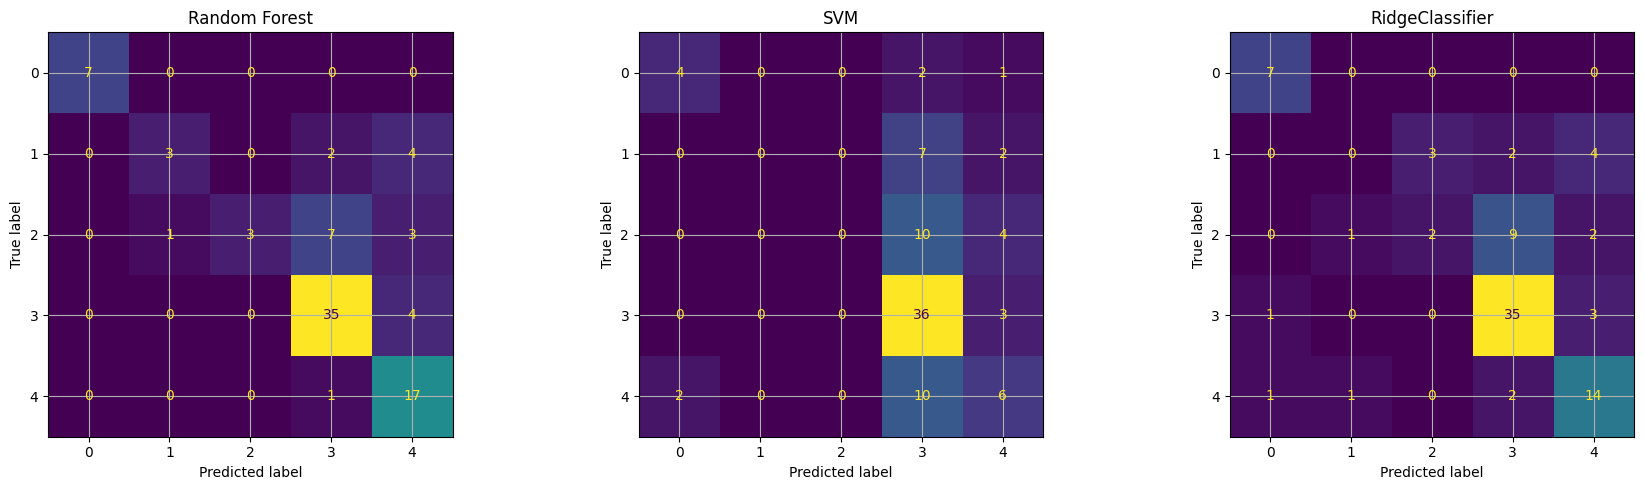

In [ ]:
techniques_in_order = ["Random Forest", "SVM", "Ridge based linear approach"]

fig, axes = plt.subplots(1, len(techniques_in_order), figsize=(18, 5))

for ax, name in zip(axes, techniques_in_order):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, values_format="d", colorbar=False)

    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

## ROC curves for multiclass comparison

Receiver Operating Characteristic (ROC) curves are used to evaluate how well each technique separates the classes across decision thresholds.  As this is a multiclass problem, ROC is computed using a one versus rest approach, where each class is treated as the positive class in turn and all other classes are treated as the negative class.  A macro averaged ROC AUC is then reported to summarise overall separability across classes.

ROC analysis requires continuous score outputs rather than only discrete class predictions.  Random Forest provides class probabilities via `predict_proba`, so ROC AUC reflects probability based ranking.  For SVM and RidgeClassifier, ROC is computed using decision scores from `decision_function` where probabilities are not available, which means the ROC analysis reflects ranking ability rather than a calibrated risk estimate.  Where suitable score outputs are not available, ROC based results are omitted and the comparison focuses on the remaining metrics and class level error patterns.

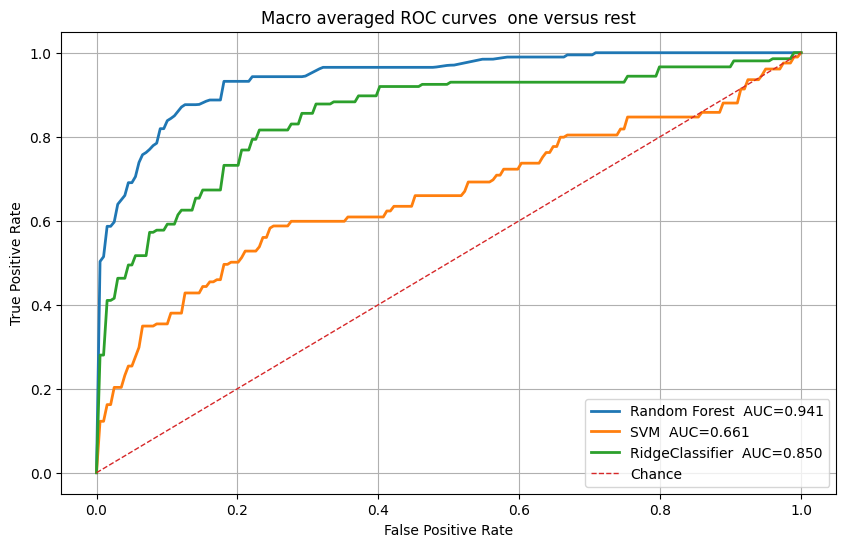

,Technique,Macro ROC AUC (OvR),Class 0 AUC,Class 1 AUC,Class 2 AUC,Class 3 AUC,Class 4 AUC
0,Random Forest,0.9415,0.9991,0.9088,0.9090,0.9364,0.9541
1,SVM,0.6606,0.9661,0.5071,0.3738,0.7949,0.6610
2,RidgeClassifier,0.8500,0.9946,0.7265,0.6624,0.9316,0.9348


In [ ]:
def align_scores_to_class_labels(fitted_pipeline, scores, class_labels):
    """
    Ensure score columns follow the same class order as class_labels.
    Many sklearn estimators output scores in the order of estimator.classes_.
    """
    if scores is None:
        return None

    scores = np.asarray(scores)

    model = fitted_pipeline.named_steps.get("model", None)
    if model is None or not hasattr(model, "classes_"):
        return scores

    model_classes = np.asarray(model.classes_)
    class_labels = np.asarray(class_labels)

    if scores.ndim != 2 or scores.shape[1] != len(model_classes):
        return scores

    index_map = []
    for c in class_labels:
        if c in model_classes:
            index_map.append(int(np.where(model_classes == c)[0][0]))
        else:
            return scores

    return scores[:, index_map]


def macro_roc_curve_from_ovr(roc_dict, n_points=200):
    """
    Build a macro averaged ROC curve by interpolating class ROC curves
    to a shared FPR grid and averaging TPR values.
    """
    mean_fpr = np.linspace(0.0, 1.0, n_points)
    tprs = []

    for c in roc_dict["class_labels"]:
        fpr_c = np.asarray(roc_dict["fpr"][c])
        tpr_c = np.asarray(roc_dict["tpr"][c])
        tprs.append(np.interp(mean_fpr, fpr_c, tpr_c))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[0] = 0.0
    mean_tpr[-1] = 1.0

    macro_auc_curve = auc(mean_fpr, mean_tpr)
    return mean_fpr, mean_tpr, macro_auc_curve


techniques_in_order = ["Random Forest", "SVM", "Ridge based linear approach"]

plt.figure(figsize=(10, 6))

roc_summary_rows = []

for name in techniques_in_order:
    fitted_model = {"Random Forest": rf_fitted, "SVM": svm_fitted, "Ridge based linear approach": linear_fitted}[name]
    scores = score_outputs.get(name, {}).get("scores", None)

    if scores is None:
        print(f"{name}: no score outputs available, ROC will be skipped")
        continue

    scores_aligned = align_scores_to_class_labels(fitted_model, scores, class_labels)

    try:
        roc_info = one_vs_rest_roc(y_test, scores_aligned, class_labels=class_labels)

        mean_fpr, mean_tpr, macro_auc_curve = macro_roc_curve_from_ovr(roc_info)
        plt.plot(mean_fpr, mean_tpr, linewidth=2, label=f"{name}  AUC={roc_info['macro_auc_ovr']:.3f}")

        row = {"Technique": name, "Macro ROC AUC (OvR)": roc_info["macro_auc_ovr"]}
        for c in roc_info["class_labels"]:
            row[f"Class {c} AUC"] = roc_info["auc_per_class"][c]
        roc_summary_rows.append(row)

    except Exception as e:
        print(f"{name}: ROC computation failed  {e}")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro averaged ROC curves  one versus rest")
plt.legend()
plt.grid(True)
plt.show()

# Per class AUC summary table
if len(roc_summary_rows) > 0:
    roc_auc_table = pd.DataFrame(roc_summary_rows)

    # Round for readability
    for col in roc_auc_table.columns:
        if col != "Technique":
            roc_auc_table[col] = roc_auc_table[col].astype(float).round(4)

    display(roc_auc_table)

## Metric comparison plots

The following figures provide a visual comparison of headline performance and computational trade offs across techniques.  The first plot compares predictive metrics to highlight differences in overall classification quality.  The second plot compares training and prediction time to support discussion of efficiency and practical deployment considerations.

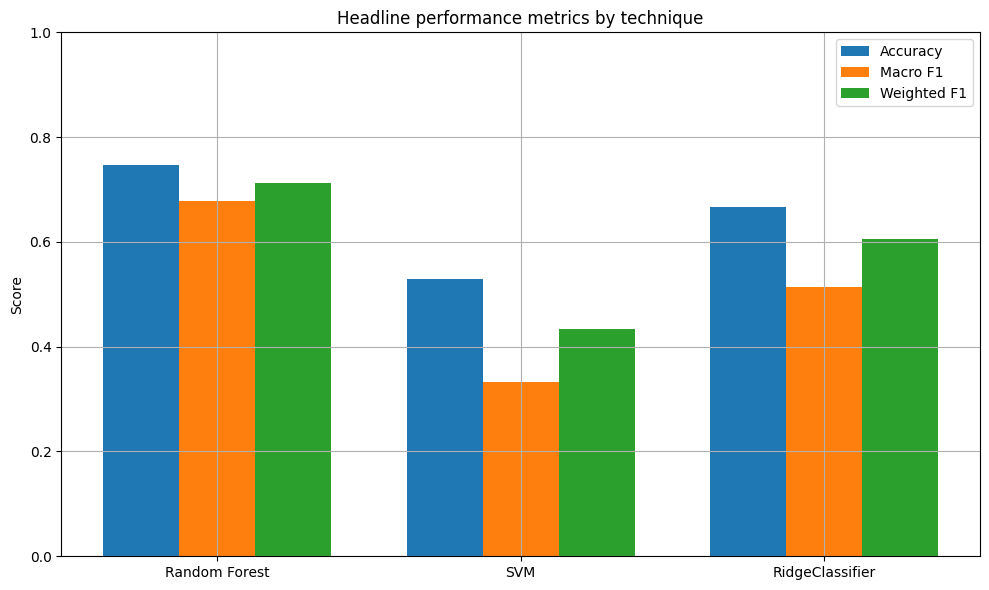

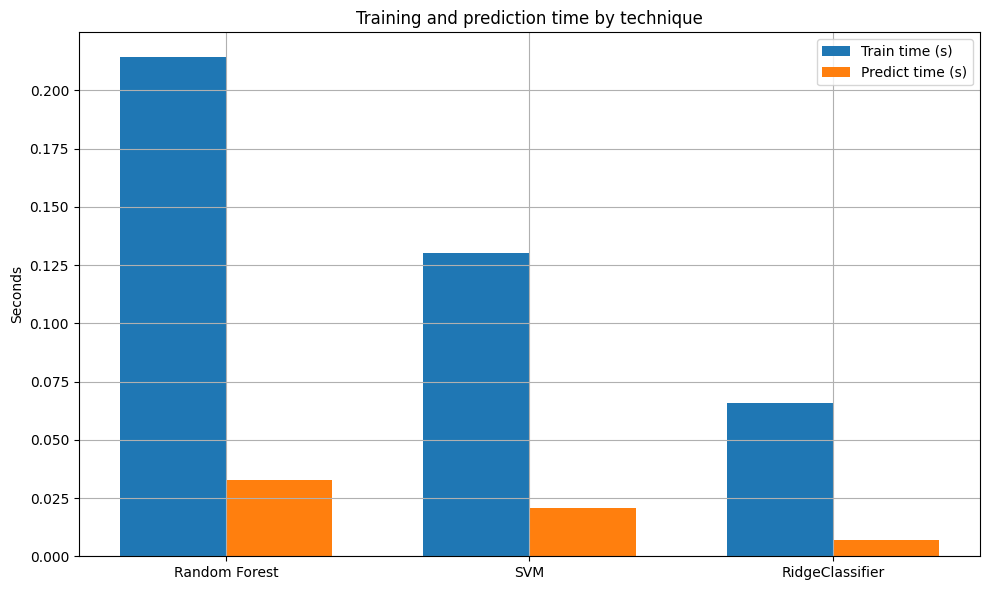

In [ ]:
techniques_in_order = ["Random Forest", "SVM", "Ridge based linear approach"]

# Build a plotting dataframe from the existing metrics table
plot_df = metrics_table.set_index("Technique").loc[techniques_in_order].reset_index()


# Plot 1  Headline predictive metrics
metric_cols = ["Accuracy", "Macro F1", "Weighted F1"]

plot_long = plot_df.melt(
    id_vars=["Technique"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(10, 6))

x = np.arange(len(techniques_in_order))
bar_width = 0.25

for i, metric_name in enumerate(metric_cols):
    values = plot_df[metric_name].astype(float).to_numpy()
    plt.bar(x + i * bar_width, values, width=bar_width, label=metric_name)

plt.xticks(x + bar_width, techniques_in_order)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Headline performance metrics by technique")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


# Plot 2  Training and prediction time
time_cols = ["Train time (s)", "Predict time (s)"]

plt.figure(figsize=(10, 6))

x = np.arange(len(techniques_in_order))
bar_width = 0.35

train_times = plot_df["Train time (s)"].astype(float).to_numpy()
pred_times = plot_df["Predict time (s)"].astype(float).to_numpy()

plt.bar(x - bar_width / 2, train_times, width=bar_width, label="Train time (s)")
plt.bar(x + bar_width / 2, pred_times, width=bar_width, label="Predict time (s)")

plt.xticks(x, techniques_in_order)
plt.ylabel("Seconds")
plt.title("Training and prediction time by technique")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## Feature importance and interpretability evidence

Interpretability differs across model families, so the supporting evidence presented for each technique is necessarily different.  Random Forest models provide native feature importance scores based on how features contribute to impurity reduction across the ensemble.  Impurity based feature importance can overstate the importance of noisy or high cardinality inputs, so the Random Forest importance results should be treated as indicative patterns rather than causal explanations.  Linear models such as RidgeClassifier provide coefficients, which can be interpreted as the direction and relative strength of each feature’s contribution to the decision boundary.

For non linear SVM models using an RBF kernel, there is no single set of global coefficients that can be interpreted in the same way as a linear model.  In this case, interpretability is supported using model agnostic methods, such as permutation importance, which estimate the impact of each feature on performance when the feature values are disrupted.  For the RBF SVM, permutation importance reflects sensitivity within the current test distribution and can be unstable, particularly where TF IDF features are correlated, so the results are best interpreted as a coarse diagnostic rather than a definitive ranking, and should be checked against repeated resamples if used for decision making.

,feature,importance
3070,text__injuries,0.022451
2893,text__hospital,0.012857
2313,text__fatal,0.012186
5151,text__serious,0.010760
1164,text__certified,0.009533
2689,text__grievous,0.008983
657,text__at,0.008710
3068,text__injured,0.008642
1665,text__death,0.008249
4017,text__old,0.008209


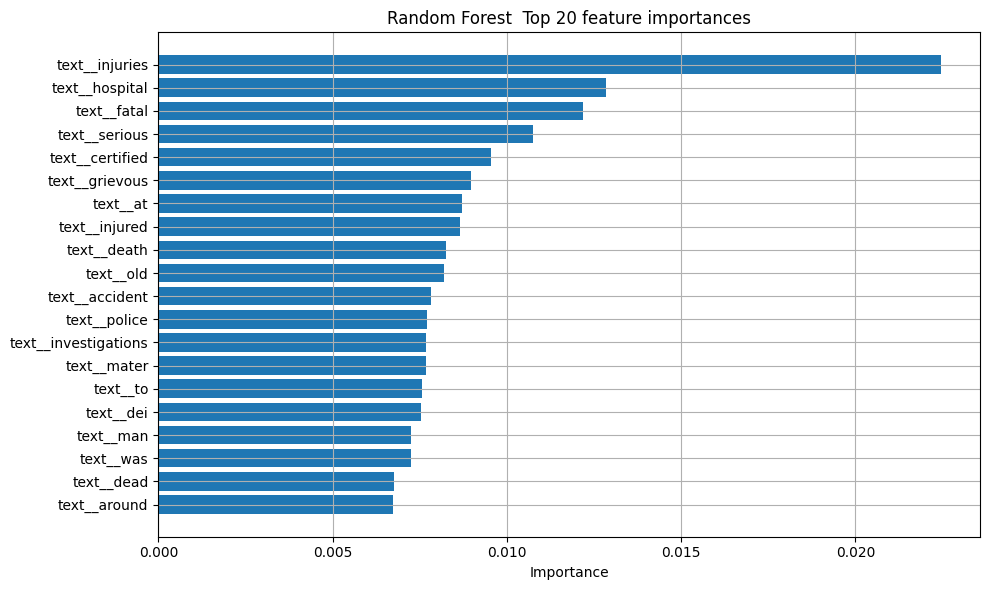

In [31]:
rf_model = rf_fitted.named_steps["model"]
rf_pre = rf_fitted.named_steps["preprocess"]

def safe_get_feature_names(preprocessor):
    names = []

    for name, transformer, cols in preprocessor.transformers_:
        if name == "remainder" and transformer == "drop":
            continue

        # Text pipeline: join then tfidf
        if hasattr(transformer, "named_steps") and "tfidf" in transformer.named_steps:
            tfidf = transformer.named_steps["tfidf"]
            try:
                vocab = tfidf.get_feature_names_out()
                names.extend([f"{name}__{v}" for v in vocab])
            except Exception:
                names.extend([f"{name}__text_feature_{i}" for i in range(tfidf.vocabulary_.__len__())])

        # Numeric pipeline: pass through list of numeric columns
        elif isinstance(cols, (list, tuple, np.ndarray, pd.Index)):
            names.extend([f"{name}__{c}" for c in cols])

        else:
            # Fallback
            names.append(f"{name}__feature")

    return np.array(names, dtype=object)

feature_names = safe_get_feature_names(rf_pre)

importances = rf_model.feature_importances_

# Safety check in case lengths mismatch
if len(feature_names) != len(importances):
    feature_names = np.array([f"feature_{i}" for i in range(len(importances))], dtype=object)

rf_imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

top_n = 20
rf_top = rf_imp_df.head(top_n).copy()

display(rf_top)

plt.figure(figsize=(10, 6))
plt.barh(rf_top["feature"][::-1], rf_top["importance"][::-1])
plt.xlabel("Importance")
plt.title(f"Random Forest  Top {top_n} feature importances")
plt.tight_layout()
plt.show()

,feature,importance_mean,importance_std
9,tag_Accident,0.084459,0.029831
12,tag_Transport,0.068855,0.019694
0,content,0.037203,0.002971
1,temperature_2m_mean,0.029305,0.016547
4,precipitation_hours,0.023598,0.009401
13,dow_sin,0.020509,0.017877
8,tag_National,0.020405,0.007101
2,apparent_temperature_mean,0.017914,0.014584
7,month,0.010865,0.008055
6,is_holiday,0.008181,0.015109


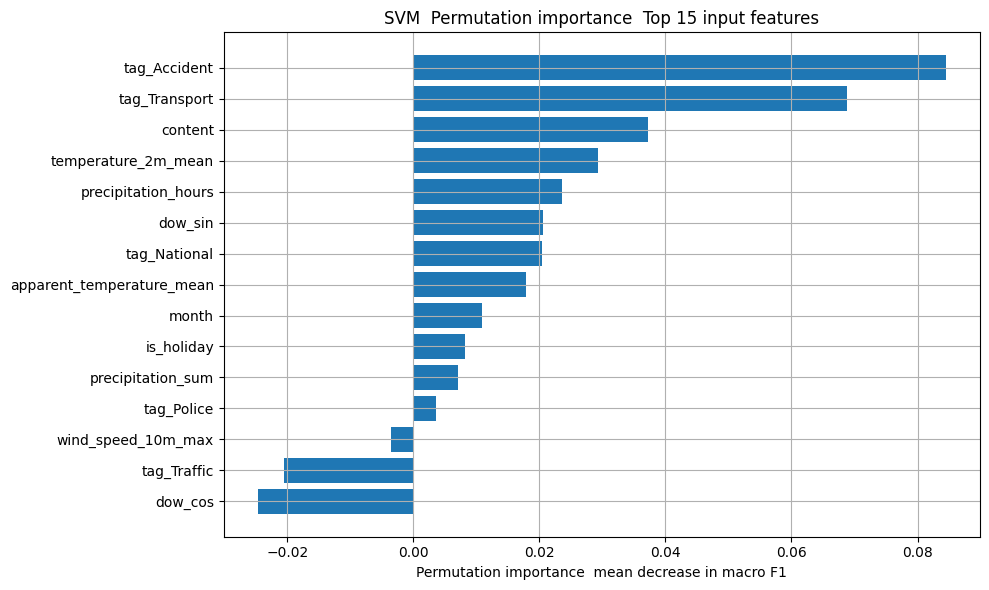

In [36]:
# Use a smaller subset for speed and stability
subset_n = min(200, len(X_test))
X_sub = X_test.iloc[:subset_n].copy()
y_sub = y_test.iloc[:subset_n].copy()

# Permutation importance is applied to the full pipeline.
# Note: This measures importance at the original input feature level, not individual TF IDF terms.
perm = permutation_importance(
    svm_fitted,
    X_sub,
    y_sub,
    n_repeats=5,
    random_state=RANDOM_SEED,
    scoring="f1_macro"
)

svm_perm_df = pd.DataFrame(
    {
        "feature": X_sub.columns.to_list(),
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

# Keep a consistent target of top 20, but cap at the number of available input features
top_n = min(20, len(svm_perm_df))
svm_top = svm_perm_df.head(top_n).copy()

display(svm_top)

plt.figure(figsize=(10, 6))
plt.barh(svm_top["feature"][::-1], svm_top["importance_mean"][::-1])
plt.xlabel("Permutation importance  mean decrease in macro F1")
plt.title(f"SVM  Permutation importance  Top {top_n} input features")
plt.tight_layout()
plt.show()

,feature,mean_abs_coef
5151,text__serious,0.805813
3070,text__injuries,0.695757
2689,text__grievous,0.575615
1659,text__dead,0.458609
2313,text__fatal,0.437683
1665,text__death,0.433200
2893,text__hospital,0.428993
3068,text__injured,0.385390
1787,text__died,0.381429
5654,text__sustained,0.351603


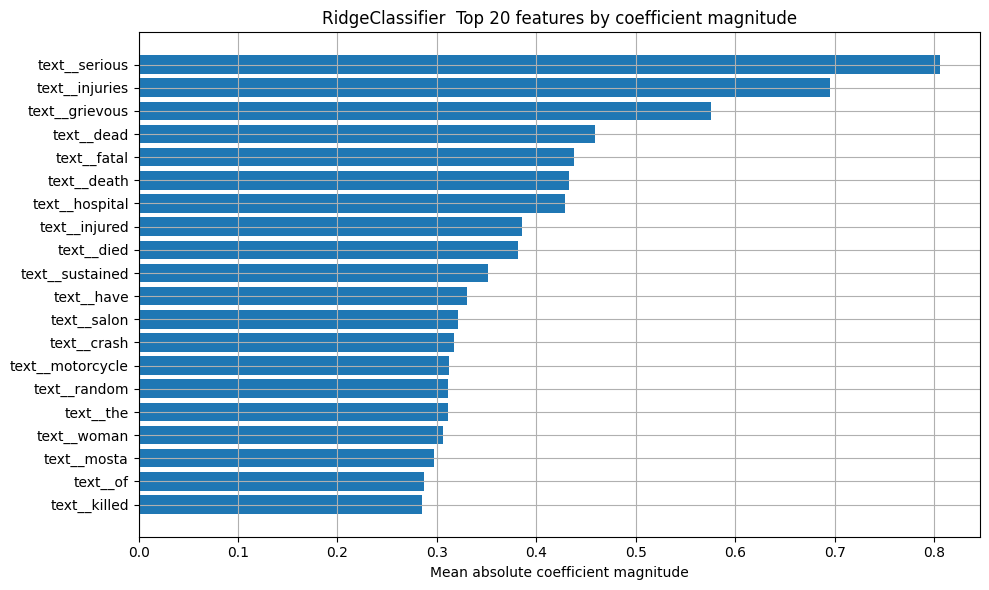

In [ ]:
ridge_model = linear_fitted.named_steps["model"]
ridge_pre = linear_fitted.named_steps["preprocess"]

# Build readable feature names for the transformed space
def get_feature_names_for_linear(preprocessor):
    names = []

    for name, transformer, cols in preprocessor.transformers_:
        if name == "remainder" and transformer == "drop":
            continue

        # Text pipeline: join then tfidf
        if hasattr(transformer, "named_steps") and "tfidf" in transformer.named_steps:
            tfidf = transformer.named_steps["tfidf"]
            vocab = tfidf.get_feature_names_out()
            names.extend([f"{name}__{v}" for v in vocab])

        # Numeric columns
        elif isinstance(cols, (list, tuple, np.ndarray, pd.Index)):
            names.extend([f"{name}__{c}" for c in cols])

        else:
            names.append(f"{name}__feature")

    return np.array(names, dtype=object)

feature_names = get_feature_names_for_linear(ridge_pre)

coefs = getattr(ridge_model, "coef_", None)

if coefs is None:
    print("Ridge based linear approach coefficients are not available in this environment.")
else:
    coefs = np.asarray(coefs)

    # Multiclass yields shape (n_classes, n_features)
    # We summarise global importance using mean absolute coefficient magnitude across classes.
    if coefs.ndim == 2:
        coef_summary = np.mean(np.abs(coefs), axis=0)
    else:
        coef_summary = np.abs(coefs)

    # Safety check
    if len(feature_names) != len(coef_summary):
        feature_names = np.array([f"feature_{i}" for i in range(len(coef_summary))], dtype=object)

    coef_df = (
        pd.DataFrame({"feature": feature_names, "mean_abs_coef": coef_summary})
        .sort_values("mean_abs_coef", ascending=False)
    )

    top_n = 20
    top_coef = coef_df.head(top_n).copy()

    display(top_coef)

    plt.figure(figsize=(10, 6))
    plt.barh(top_coef["feature"][::-1], top_coef["mean_abs_coef"][::-1])
    plt.xlabel("Mean absolute coefficient magnitude")
    plt.title(f"Ridge based linear approach  Top {top_n} features by coefficient magnitude")
    plt.tight_layout()
    plt.show()

## Significance testing approach

The headline metrics above show clear differences in macro F1 across techniques.  However, a single test split can contain sampling noise, especially where some classes have small support.  The purpose of significance testing in this section is therefore to assess whether the observed macro F1 gaps are likely to reflect a real performance difference, rather than variation that could plausibly occur by chance on a different sample of test cases.

We use a paired resampling approach on the same held out test set.  For each bootstrap replicate, we resample test rows with replacement, recompute macro F1 for each technique, and then compute the paired difference in macro F1 between techniques.  This yields an empirical distribution of macro F1 differences, from which we report the mean difference and a 95 percent confidence interval.  If the confidence interval does not include zero, the difference is treated as practically meaningful under this evaluation protocol.

In [ ]:
# Techniques to compare
techniques = ["Random Forest", "SVM", "Ridge based linear approach"]

# Convert to NumPy once for speed and to avoid index alignment issues
y_true = np.asarray(y_test)

y_preds = {}
for name in techniques:
    y_preds[name] = np.asarray(predictions[name])

# Bootstrap settings
n_boot = 2000
rng = np.random.default_rng(RANDOM_SEED)

n = len(y_true)
boot_diffs = {}

pairs = []
for i in range(len(techniques)):
    for j in range(i + 1, len(techniques)):
        pairs.append((techniques[i], techniques[j]))

for a, b in pairs:
    boot_diffs[(a, b)] = np.zeros(n_boot, dtype=float)

# Run paired bootstrap
for b_i in range(n_boot):
    idx = rng.integers(0, n, size=n)

    y_bs = y_true[idx]

    f1_scores = {}
    for name in techniques:
        f1_scores[name] = f1_score(y_bs, y_preds[name][idx], average="macro")

    for a, b in pairs:
        boot_diffs[(a, b)][b_i] = f1_scores[a] - f1_scores[b]

# Summarise results
rows = []
for a, b in pairs:
    diffs = boot_diffs[(a, b)]
    mean_diff = float(np.mean(diffs))
    ci_low = float(np.percentile(diffs, 2.5))
    ci_high = float(np.percentile(diffs, 97.5))

    rows.append(
        {
            "Comparison": f"{a} vs {b}",
            "Mean macro F1 difference": mean_diff,
            "95 percent CI lower": ci_low,
            "95 percent CI upper": ci_high,
        }
    )

sig_table = pd.DataFrame(rows)

# Round for readability
for col in ["Mean macro F1 difference", "95 percent CI lower", "95 percent CI upper"]:
    sig_table[col] = sig_table[col].round(4)

display(sig_table)

#  Save for later export cell
sig_csv_path = "bootstrap_macro_f1_significance.csv"
sig_table.to_csv(sig_csv_path, index=False)
print(f"Saved significance table to: {sig_csv_path}")

,Comparison,Mean macro F1 difference,95 percent CI lower,95 percent CI upper
0,Random Forest vs SVM,0.3414,0.2038,0.4805
1,Random Forest vs RidgeClassifier,0.1587,0.0397,0.2757
2,SVM vs RidgeClassifier,-0.1827,-0.2867,-0.0761


Saved significance table to: bootstrap_macro_f1_significance.csv


## Trade off analysis

The comparative results show a clear performance ranking under the shared evaluation protocol.  Random Forest achieves the strongest predictive performance overall, with the highest accuracy, macro F1, weighted F1, and macro ROC AUC.  RidgeClassifier provides a competitive second best option, while the SVM configuration underperforms substantially, including failing to predict some minority classes reliably as reflected in its low macro F1 and weaker ROC AUC.

These conclusions are supported by the paired bootstrap analysis on the held out test set, which indicates that the observed macro F1 differences are unlikely to be explained purely by sampling noise under this dataset and split.  At the same time, this uncertainty estimate is specific to the current held out test set and should not be interpreted as a guarantee of identical margins on future data without additional validation.

Accuracy versus interpretability:

Random Forest offers the best accuracy and separability, but its decision process is less transparent at the individual prediction level.  Feature importance provides some global interpretability, yet it remains an ensemble of many trees and is harder to explain case by case.  RidgeClassifier is more interpretable because the model is linear and provides coefficients that indicate which features push the decision boundary.  The SVM with an RBF kernel is the least interpretable in a direct sense, requiring model agnostic methods such as permutation importance, which are informative but less straightforward to communicate.

Complexity versus performance:

Random Forest is the most complex model family in this comparison, but that complexity delivers the strongest performance, particularly in macro averaged metrics and ROC AUC.  RidgeClassifier is substantially simpler, and although it yields lower performance than Random Forest, it remains competitive and provides clearer interpretability.  The SVM configuration used here does not justify its complexity because the performance is markedly lower, especially for minority class recognition.

Training time versus prediction speed: 

The timing results highlight a practical deployment trade off.  Random Forest has the highest training and prediction time among the three techniques, though the absolute times remain small in this notebook environment.  RidgeClassifier is the fastest in both training and prediction, offering the best efficiency profile.  The SVM sits between the two in runtime, but its weaker predictive performance makes the speed benefit insufficient under the current configuration.

Overall, the results suggest that Random Forest is the best choice when maximising predictive performance is the primary objective, while RidgeClassifier is a strong alternative when simplicity, speed, and interpretability are prioritised.  The current SVM configuration is not recommended due to consistently weaker macro F1 and class level performance.

## Ethical analysis  proxy variables and temporal bias

A comparative evaluation is incomplete without considering how model inputs may encode sensitive information or introduce systematic bias.  In this dataset, some structured fields can plausibly act as proxy variables, and some fields may introduce temporal bias if the underlying reporting environment or incident patterns change over time.

Proxy variables  location as a proxy:

If any location related feature is present, it can unintentionally function as a proxy for demographic or socio economic differences between areas.  Even where the model is not explicitly given sensitive attributes, geographic features may correlate with enforcement intensity, infrastructure quality, population density, or community level risk factors.  This creates a risk that the model learns area specific patterns that reflect historical inequities rather than true severity.  In deployment, this could lead to uneven performance across locations and potentially unfair outcomes, for example systematically over estimating severity in some areas or under estimating severity in others.

Temporal bias  time as a proxy:

If time fields are present, such as month, day of week features, or other temporal indicators, they can encode shifting patterns in both incidents and reporting practices.  For example, seasonal changes, policy changes, or changes in data collection can cause the relationship between inputs and severity to drift.  A model that performs well on one period may therefore degrade on later periods or behave differently during specific times of the year.  This risk is amplified when the dataset is limited in size, because the model may over learn short term patterns that do not generalise.

In the following checks, we examine grouped performance across available location and time attributes.  The goal is not to claim discrimination from aggregate differences alone, but to identify potential risk signals that warrant safeguards, monitoring, and human oversight before real world deployment.

In [ ]:

# If a location style column exists, report metrics by location.
# If a time style column exists, report metrics by time buckets.
test_view = df.loc[test_idx].copy()
test_view["y_true"] = y_test.values

# Attach each model prediction to the same test view
techniques = ["Random Forest", "SVM", "Ridge based linear approach"]
for name in techniques:
    test_view[f"pred_{name}"] = np.asarray(predictions[name])

def grouped_metrics(table, group_col, technique_names):
    rows = []
    for group_value, g in table.groupby(group_col):
        n = len(g)
        if n == 0:
            continue

        y_true_g = g["y_true"].to_numpy()

        for tech in technique_names:
            y_pred_g = g[f"pred_{tech}"].to_numpy()

            rows.append(
                {
                    "Group column": group_col,
                    "Group value": group_value,
                    "Technique": tech,
                    "n": n,
                    "Accuracy": accuracy_score(y_true_g, y_pred_g),
                    "Macro F1": f1_score(y_true_g, y_pred_g, average="macro"),
                    "Weighted F1": f1_score(y_true_g, y_pred_g, average="weighted"),
                }
            )

    out = pd.DataFrame(rows)
    if not out.empty:
        out["Accuracy"] = out["Accuracy"].astype(float).round(4)
        out["Macro F1"] = out["Macro F1"].astype(float).round(4)
        out["Weighted F1"] = out["Weighted F1"].astype(float).round(4)
    return out


# Proxy check  location like columns
location_candidates = [
    "location", "area", "region", "district", "locality", "city", "town", "village",
    "postcode", "zip", "lat", "lon", "latitude", "longitude"
]

location_cols_present = [c for c in test_view.columns if c.lower() in location_candidates]

if len(location_cols_present) == 0:
    print("No location like column detected in the dataset.  Location proxy check skipped.")
else:
    loc_col = location_cols_present[0]
    print(f"Location like column detected: {loc_col}")

    loc_table = grouped_metrics(test_view, loc_col, techniques)

    if loc_table.empty:
        print("Location grouping produced no rows.  Check that the column contains values.")
    else:
        display(loc_table.sort_values(["Group value", "Technique"]).reset_index(drop=True))


# Temporal check  time like columns

time_candidates_priority = ["year", "date", "datetime", "timestamp", "month"]

time_cols_present = [c for c in test_view.columns if c.lower() in time_candidates_priority]

if len(time_cols_present) == 0:
    print("No time like column detected in the dataset.  Temporal bias check skipped.")
else:
    # Prefer year, then date, then month
    chosen_time_col = None
    for preferred in ["year", "date", "datetime", "timestamp", "month"]:
        for c in time_cols_present:
            if c.lower() == preferred:
                chosen_time_col = c
                break
        if chosen_time_col is not None:
            break

    print(f"Time like column selected: {chosen_time_col}")

    # If month exists and looks numeric, bucket by month directly
    # If date or datetime exists, parse and bucket by month
    temp_view = test_view.copy()

    if chosen_time_col.lower() in {"date", "datetime", "timestamp"}:
        temp_view["_parsed_time"] = pd.to_datetime(temp_view[chosen_time_col], errors="coerce")
        temp_view["_time_bucket"] = temp_view["_parsed_time"].dt.to_period("M").astype(str)
        bucket_col = "_time_bucket"
    elif chosen_time_col.lower() == "year":
        temp_view["_time_bucket"] = temp_view[chosen_time_col].astype(str)
        bucket_col = "_time_bucket"
    elif chosen_time_col.lower() == "month":
        temp_view["_time_bucket"] = temp_view[chosen_time_col].astype(int)
        bucket_col = "_time_bucket"
    else:
        temp_view["_time_bucket"] = temp_view[chosen_time_col].astype(str)
        bucket_col = "_time_bucket"

    time_table = grouped_metrics(temp_view, bucket_col, techniques)

    if time_table.empty:
        print("Temporal grouping produced no rows.  Check that the column contains values.")
    else:
        display(time_table.sort_values(["Group value", "Technique"]).reset_index(drop=True))

No location like column detected in the dataset.  Location proxy check skipped.
Time like column selected: month


,Group column,Group value,Technique,n,Accuracy,Macro F1,Weighted F1
0,_time_bucket,1,Random Forest,9,0.7778,0.6167,0.7407
1,_time_bucket,1,RidgeClassifier,9,0.6667,0.3667,0.5926
2,_time_bucket,1,SVM,9,0.6667,0.3333,0.5741
3,_time_bucket,2,Random Forest,9,0.7778,0.6667,0.7037
4,_time_bucket,2,RidgeClassifier,9,0.6667,0.6000,0.6444
5,_time_bucket,2,SVM,9,0.5556,0.3485,0.3973
6,_time_bucket,3,Random Forest,3,1.0000,1.0000,1.0000
7,_time_bucket,3,RidgeClassifier,3,0.6667,0.5556,0.5556
8,_time_bucket,3,SVM,3,0.6667,0.5556,0.5556
9,_time_bucket,4,Random Forest,9,0.7778,0.5079,0.7196


## Fairness across groups

The grouped results above are intended as a risk check rather than a definitive fairness audit.  Observed performance gaps between groups can arise for several reasons, including genuine differences in data generating conditions, sample size effects, and model limitations.  For this reason, group level metrics should be interpreted alongside the corresponding group counts, and any conclusions should be framed cautiously, particularly where support is small.

Imbalance and small group effects:

Several time buckets contain only a small number of test cases.  In such settings, metrics such as macro F1 can vary sharply from month to month, and even perfect scores may occur by chance.  This means that apparent temporal differences may reflect sampling variation rather than stable seasonal behaviour.  Where small n is present, the safer interpretation is that the model’s reliability is uncertain for that period and warrants monitoring rather than strong claims.

Label noise and reporting effects:

Severity labels can contain noise due to subjective judgement, inconsistent reporting standards, or changes in how incidents are documented.  If labelling practices differ across time periods, then group performance gaps may reflect label inconsistency rather than true model bias.  This is particularly relevant when text fields are included, as terminology and reporting style can drift over time.

Potential harms:

If a deployed system performs unevenly across groups or time periods, it can create real harms.  Under prediction of higher severity cases during certain months could delay prioritisation and response, while over prediction could lead to unnecessary escalation, resource misallocation, or reduced trust in the system.  In addition, if temporal features or other structured attributes correlate with unobserved sensitive factors, the model may indirectly reproduce historical patterns that are not ethically desirable.

No explicit geographic variable is available in this dataset, so geographic fairness cannot be assessed directly here, and fairness is instead evaluated across available operational conditions and temporal buckets such as holiday status, incident tag groups, and month.

Overall, these results motivate safeguards rather than definitive fairness conclusions.  The most appropriate next steps are to report group counts transparently, avoid over interpreting small group metrics, and implement monitoring so that performance drift or emerging group disparities are detected early in deployment.

,Bucket,Technique,n,Accuracy,Macro F1,Weighted F1
0,1,Random Forest,9,0.7778,0.6167,0.7407
1,1,RidgeClassifier,9,0.6667,0.3667,0.5926
2,1,SVM,9,0.6667,0.3333,0.5741
3,2,Random Forest,9,0.7778,0.6667,0.7037
4,2,RidgeClassifier,9,0.6667,0.6000,0.6444
5,2,SVM,9,0.5556,0.3485,0.3973
6,3,Random Forest,3,1.0000,1.0000,1.0000
7,3,RidgeClassifier,3,0.6667,0.5556,0.5556
8,3,SVM,3,0.6667,0.5556,0.5556
9,4,Random Forest,9,0.7778,0.5079,0.7196


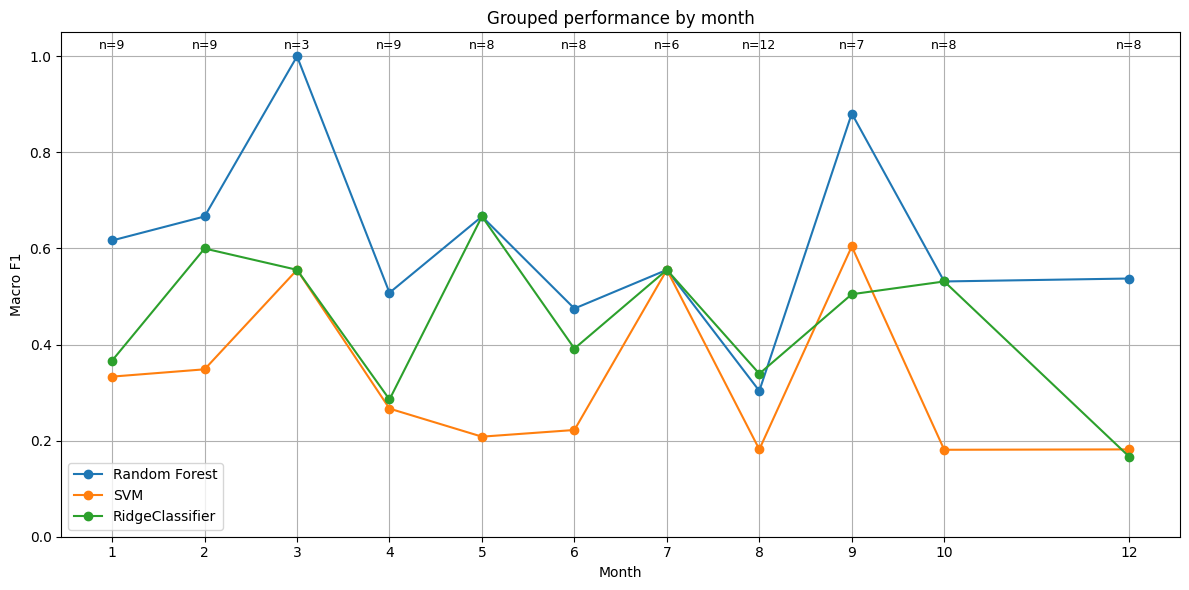

In [ ]:
def make_grouped_table(source_table, bucket_col, technique_names):
    rows = []
    for bucket_value, g in source_table.groupby(bucket_col):
        n = len(g)
        if n == 0:
            continue

        y_true_g = g["y_true"].to_numpy()

        for tech in technique_names:
            y_pred_g = g[f"pred_{tech}"].to_numpy()
            rows.append(
                {
                    "Bucket": bucket_value,
                    "Technique": tech,
                    "n": n,
                    "Accuracy": accuracy_score(y_true_g, y_pred_g),
                    "Macro F1": f1_score(y_true_g, y_pred_g, average="macro"),
                    "Weighted F1": f1_score(y_true_g, y_pred_g, average="weighted"),
                }
            )

    out = pd.DataFrame(rows)
    if not out.empty:
        out["Accuracy"] = out["Accuracy"].astype(float).round(4)
        out["Macro F1"] = out["Macro F1"].astype(float).round(4)
        out["Weighted F1"] = out["Weighted F1"].astype(float).round(4)
    return out


# Build a test view with predictions
test_view = df.loc[test_idx].copy()
test_view["y_true"] = y_test.values

techniques = ["Random Forest", "SVM", "Ridge based linear approach"]
for name in techniques:
    test_view[f"pred_{name}"] = np.asarray(predictions[name])

# Decide grouping column
location_candidates = {
    "location", "area", "region", "district", "locality", "city", "town", "village",
    "postcode", "zip", "lat", "lon", "latitude", "longitude"
}
location_cols_present = [c for c in test_view.columns if c.lower() in location_candidates]

if len(location_cols_present) > 0:
    group_col = location_cols_present[0]
    group_title = f"Grouped performance by {group_col}"
    grouped_source = test_view.copy()
else:
    if "month" not in test_view.columns:
        raise ValueError("No location column and no month column found.  Cannot build grouped fairness plot.")
    grouped_source = test_view.copy()
    grouped_source["Bucket"] = grouped_source["month"].astype(int)
    group_col = "Bucket"
    group_title = "Grouped performance by month"

# Create table
fairness_table = make_grouped_table(grouped_source.rename(columns={group_col: "Bucket"}), "Bucket", techniques)

if fairness_table.empty:
    print("No grouped rows were produced.  Check that the grouping column contains values.")
else:
    display(fairness_table.sort_values(["Bucket", "Technique"]).reset_index(drop=True))

    # Ensure bucket is numeric for plotting order
    fairness_table["Bucket"] = fairness_table["Bucket"].astype(int)

    # Sample size per bucket
    n_by_bucket = fairness_table[["Bucket", "n"]].drop_duplicates().set_index("Bucket")["n"]

    # Pivot macro F1 for plotting
    pivot_f1 = fairness_table.pivot(index="Bucket", columns="Technique", values="Macro F1").sort_index()

    plt.figure(figsize=(12, 6))

    for tech in techniques:
        if tech in pivot_f1.columns:
            plt.plot(pivot_f1.index.to_numpy(), pivot_f1[tech].to_numpy(), marker="o", label=tech)

    # Annotate sample sizes at the top of the plot for each bucket
    for b in pivot_f1.index.to_numpy():
        n_val = int(n_by_bucket.loc[b]) if b in n_by_bucket.index else None
        if n_val is not None:
            plt.text(b, 1.01, f"n={n_val}", ha="center", va="bottom", fontsize=9)

    plt.ylim(0, 1.05)
    plt.xticks(pivot_f1.index.to_numpy(), [str(int(x)) for x in pivot_f1.index.to_numpy()])
    plt.xlabel("Month" if group_title == "Grouped performance by month" else "Bucket")
    plt.ylabel("Macro F1")
    plt.title(group_title)
    plt.grid(True, axis="y")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Transparency and deployment risks

Transparency differs substantially across the three techniques.  Random Forest provides strong predictive performance, but it is less transparent at the individual prediction level because decisions arise from an ensemble of many trees.  RidgeClassifier is more transparent because it is linear and offers coefficient based explanations that can be summarised consistently.  The SVM configuration used here is the least transparent in practice, as its non linear kernel requires indirect explanation methods such as permutation importance, which are harder to communicate to non technical stakeholders.

False positives and false negatives have different practical costs in deployment.  If the system under predicts higher severity cases, this could delay prioritisation, reduce responsiveness, or create safety risks.  If the system over predicts severity, it may trigger unnecessary escalation, consume limited resources, or reduce trust in the model due to frequent false alarms.  These risks are amplified for minority classes because class level errors can be masked by overall accuracy, which is why macro averaged metrics and confusion matrices are included in the evaluation.

Policy impacts and feedback loops must also be considered.  If model outputs are used to allocate attention or resources, the system may influence what gets recorded and how it gets recorded over time.  This can create feedback loops where areas, months, or incident types that receive more scrutiny generate more detailed records, which then further reinforces the model’s learned patterns.  To avoid self reinforcing bias, deployment should include clear guidance on how predictions are used, routine auditing of performance over time, and safeguards that preserve human judgement in high impact decisions.

## Safeguards and human oversight

To reduce the risk of harm and support responsible deployment, the model should operate within a clear human in the loop workflow rather than acting as an automatic decision maker.  The safeguards below focus on preventing over reliance, detecting performance drift, and ensuring accountability.

Human review thresholds:

Predictions associated with higher operational impact should be routed for human review.  Practical triggers include low model confidence, disagreement between model families, or cases containing language patterns associated with severe outcomes.  A simple operational rule is to require human confirmation for the highest severity class and for any cases where the margin between the top two predicted classes is small, because these are more likely to be unstable.  Human reviewers should be given a short explanation summary, for example top contributing terms or top input features, rather than only a raw class label.

Monitoring and drift checks:

Performance should be monitored continuously after deployment using the same metrics used in evaluation, especially macro F1 and class level recall.  Monitoring should be broken down by time buckets such as month, and by any available operational grouping variables.  If macro F1 or recall for critical classes falls below a defined threshold, the model should be flagged for investigation and potential retraining.  Data drift checks should also be included, for example monitoring changes in the distribution of key features and in the vocabulary of the text field.

Audit logging and traceability:

Every prediction should be logged with a timestamp, model version, input feature summary, predicted class, and any score or confidence value used to make the decision.  Where applicable, store the explanation artefact, such as feature importance snapshots or coefficient based summaries.  This supports later auditing, incident review, and accountability, and it enables a clear trail when users challenge outcomes.

Governance for proxy features, including location:

If location features are introduced in future versions, they should be governed explicitly because they can act as proxies for sensitive or socio economic attributes.  Recommended controls include documenting the rationale for including location, restricting granularity to avoid over specific area effects, and auditing performance by location before and after deployment.  If disparities are observed, mitigations should be applied, for example removing the feature, coarsening it, or applying constraints and monitoring that prevent the model from over relying on it.

Together, these safeguards ensure that the system remains transparent, contestable, and subject to human judgement, while also providing early warning signals when performance changes over time or across operational contexts.

## Final recommendations and deployment considerations

Based on the shared split evaluation, the **recommended technique is Random Forest**, with **RidgeClassifier as the backup option**.  The SVM configuration evaluated here is not recommended for deployment because it delivers substantially weaker macro F1 and inconsistent class level behaviour.

Random Forest is selected as the primary model because it provides the strongest predictive quality across all headline measures.  It achieves the highest accuracy (0.7471), macro F1 (0.6774), weighted F1 (0.7115), and macro ROC AUC (0.9415).  The paired bootstrap results also support that these gains are meaningful under this evaluation protocol, with macro F1 differences that remain positive and exclude zero in the 95 percent confidence intervals versus both SVM (mean 0.3414, CI 0.2038 to 0.4805) and RidgeClassifier (mean 0.1587, CI 0.0397 to 0.2757).  Interpretability evidence is available via feature importance, which highlights clinically and operationally plausible terms in the text field, such as injuries, fatal, death, and hospital, supporting trust and qualitative validation.

RidgeClassifier is recommended as the backup because it offers a strong balance of performance, efficiency, and transparency.  While it trails Random Forest on predictive quality, it still achieves moderate accuracy (0.6667) and macro F1 (0.5146), with a solid macro ROC AUC (0.8500).  It is also the fastest technique in this comparison, with the lowest training time (0.0658 seconds) and prediction time (0.0071 seconds), making it attractive when latency or resource constraints are dominant.  Its linear coefficients provide clearer explanations than the ensemble model, which is valuable when human oversight and explainability are prioritised.

SVM is not recommended in its current configuration.  It records the weakest overall results, including accuracy (0.5287), macro F1 (0.3321), and macro ROC AUC (0.6606).  The bootstrap results indicate that RidgeClassifier meaningfully outperforms SVM on macro F1 (mean difference minus 0.1827, CI minus 0.2867 to minus 0.0761).  In addition, interpretability is less direct because the kernel based decision boundary requires model agnostic explanation methods, and the observed class level errors suggest reliability concerns for minority classes.

Deployment considerations:

Latency and throughput should be measured in the target environment rather than assumed from notebook timings.  Random Forest prediction is slower than RidgeClassifier in this environment, but the absolute times remain small, so the practical impact depends on the expected request volume and infrastructure.  A simple approach is to deploy Random Forest as the default model and retain RidgeClassifier as a fallback where fast responses are required, or where operational policy demands simpler explanations.

Maintenance and monitoring are essential.  Performance should be tracked over time using macro F1 and class level recall, and checked by time buckets such as month to detect drift.  Retraining should be scheduled regularly, for example quarterly, and triggered earlier if monitoring shows sustained degradation or systematic changes in input distributions, especially changes in the text field vocabulary and tag frequencies.

Documentation should include a short model card describing the training data, the shared split evaluation protocol, the headline metrics, known limitations such as small group sizes in some months, and intended use.  Every prediction should be audit logged with model version, timestamp, input summary, predicted class, and the score type used.  This ensures traceability, supports review workflows, and enables governance if additional proxy features such as location are introduced in future versions.

## AI Tools Used

This work was completed using a mix of LLMs assistants, primarily GPT and Gemini, to support the writing and decision making process.  GPT was used to help structure the Notebook 4 report style narrative, to structure concise markdown sections aligned with the assignment brief.  Gemini was used as a secondary tool to cross check section completeness against the brief and to double check whether the narrative interpretations matched the quantitative evidence.

Some decisions were guided by AI suggestions, but the implementations and resulting plots were produced and validated within the notebook, ensuring that the final conclusions are based on reproducible outputs rather than unverified text.